# Aula 05 — Funções (`def`) e tratamento de erros (`try/except`)

**Semana 3 | Aula de 50 min | Referências: McKinney, *Python for Data Analysis* (2012), Apêndice A — "Python Language Essentials" (seções *Functions* e *Exception handling*); VanderPlas, *Python Data Science Handbook*, cap. 1.**

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Escrever **funções puras** com `def`, docstrings e `return` para cálculos econômicos (elasticidade-preço, parcela Price/SAC, VPL);
- Distinguir argumentos **posicionais**, **nomeados** e com **valor padrão**, e escolher a forma certa em cada chamada;
- Proteger código contra entradas sujas com `try` / `except` / `else` / `finally`, capturando o tipo de erro específico (`ValueError`, `ZeroDivisionError`);
- Sanitizar valores de planilhas de clientes ("R$ 1.234,56" → `1234.56`) sem derrubar o notebook;
- Compor funções pequenas num mini-relatório executivo.

## 1. Primeira função: elasticidade-preço da demanda

**Intuição econômica.** O açougue do seu tio em Goiânia subiu o kg do coxão mole de
R$ 38,90 para R$ 42,30 e as vendas semanais caíram de 320 para 290 kg. Ele pergunta:
"subi o preço, vendi menos — valeu?". A resposta é a **elasticidade-preço da demanda**:

$$\varepsilon_D = \frac{\%\Delta Q}{\%\Delta P}$$

Se $|\varepsilon| > 1$ (elástica), aumento de preço derruba a receita $P \cdot Q$;
se $|\varepsilon| < 1$ (inelástica), aumenta. Função pura: entra 4 números, sai 1 número —
sem efeitos colaterais, sem "olhar" nada além dos argumentos.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade

In [2]:
# Nossa primeira função: docstring + cálculo + return
def elasticidade_preco(p_inicial, p_final, q_inicial, q_final):
    """Elasticidade-preço da demanda (arco percentual simples).

    Parameters
    ----------
    p_inicial, p_final : float
        Preços unitários (R$) antes e depois.
    q_inicial, q_final : float
        Quantidades vendidas antes e depois.

    Returns
    -------
    float
        ε = (%ΔQ)/(%ΔP) — normalmente negativo (lei da demanda).
    """
    variacao_p = (p_final - p_inicial) / p_inicial   # %ΔP em decimal
    variacao_q = (q_final - q_inicial) / q_inicial   # %ΔQ em decimal
    return variacao_q / variacao_p

# Dados do açougue (Goiânia, coxão mole)
eps = elasticidade_preco(38.90, 42.30, 320, 290)
print(f"Elasticidade-preço: ε = {eps:.3f}")
# Receita antes vs depois: elástica => preço subiu, receita caiu
print(f"Receita antes:  {brl(38.90 * 320)}")
print(f"Receita depois: {brl(42.30 * 290)}")

Elasticidade-preço: ε = -1.073
Receita antes:  R$ 12.448,00
Receita depois: R$ 12.267,00


**Leitura do resultado.** ε ≈ −1,07 → demanda **elástica**. O reajuste de +8,74% no preço
custou −9,38% em quantidade: a receita caiu de R$ 12.448,00 para R$ 12.267,00. Para o
açougue, a margem bruta por kg precisa compensar a perda de volume — ou o preço não vale.

Repare no contrato da função: quem chama precisa saber **a ordem** dos 4 argumentos.
É o assunto da seção 3 — mas antes, um refinamento de método.

## 2. Refinamento: fórmula do arco (ponto médio)

**Intuição.** A elasticidade "simples" muda se o preço sobe ou desce (base diferente).
Economistas usam a fórmula **arco**: dividir as variações pela **média** dos valores,
que é simétrica. Mesmo dado, resposta um pouco mais elástica.

In [3]:
# Mesma ideia, base = ponto médio (fórmula arco)
def elasticidade_arco(p_inicial, p_final, q_inicial, q_final):
    """Elasticidade-preço pela fórmula do arco (ponto médio)."""
    p_medio = (p_inicial + p_final) / 2
    q_medio = (q_inicial + q_final) / 2
    delta_p = (p_final - p_inicial) / p_medio
    delta_q = (q_final - q_inicial) / q_medio
    return delta_q / delta_p

eps_arco = elasticidade_arco(38.90, 42.30, 320, 290)
print(f"Elasticidade ponto:  {eps:.3f}")   # função da seção 1
print(f"Elasticidade arco:   {eps_arco:.3f}")

Elasticidade ponto:  -1.073
Elasticidade arco:   -1.175


A conclusão executiva não muda (elástica nos dois casos), mas o número muda: **−1,07
vs −1,18**. Quando o relatório cita elasticidade, cite a fórmula — não existe "a" elasticidade,
existe a elasticidade **calculada por um método declarado**.

## 3. Argumentos posicionais, nomeados e valores padrão

**Intuição.** Em consultoria, algumas coisas mudam a cada projeto (fluxos, preços) e
outras quase nunca (convenções, casas decimais). Posicionais para o que é essencial;
**valores padrão** para o que é quase sempre igual; **nomeados** para chamadas longas
que precisam se auto-explicar.

In [4]:
# VPL: taxa e fluxos são obrigatórios (posicionais);
# docstring documenta o contrato — padrões ficam para as aulas seguintes
def vpl(taxa, fluxos):
    """Valor Presente Líquido.

    Parameters
    ----------
    taxa : float
        Taxa de desconto por período, em decimal (0.139 = 13,9% a.a.).
    fluxos : list[float]
        Fluxos de caixa; o investimento entra como valor NEGATIVO no índice 0.

    Returns
    -------
    float
        VPL em R$.
    """
    return sum(fc / (1 + taxa) ** t for t, fc in enumerate(fluxos))

# Fluxos do projeto silo (a Aula 15 usará isto de novo): capex R$ 850 mil
fluxos_silo = [-850_000, 280_000, 310_000, 290_000, 300_000, 260_000]
taxa = 0.139            # Selic set/2026 — custo de oportunidade do capital

# 1) posicional
print(f"VPL (posicional): {brl(vpl(taxa, fluxos_silo))}")
# 2) nomeado — ordem trocada, mesmo resultado
print(f"VPL (nomeado):    {brl(vpl(fluxos=fluxos_silo, taxa=taxa))}")

VPL (posicional): R$ 144.919,77
VPL (nomeado):    R$ 144.919,77


**Regras de bolso:**
- Obrigatórios primeiro, com padrão depois (`def f(a, b, padrao=1)` — nunca o contrário);
- Em chamadas longas, use nomeados: `vpl(fluxos=..., taxa=...)` evita a clássica troca
  de taxa com fluxo;
- Variáveis criadas dentro da função são **locais**: morrem quando a função termina.
  A `taxa` de dentro não suja (nem usa) a `taxa` de fora.

## 4. Amortização: tabela Price e SAC

**Intuição econômica.** Financiamento de R$ 320 mil para um trator (agro de Goiás),
em 48 prestações mensais a 1,09% a.m. (≈ 13,9% a.a. — Selic set/2026 como referência
de custo de dinheiro). Duas tabelas dominam o mercado:

- **Price**: parcela fixa — bom para o fluxo de caixa do cliente;
- **SAC**: amortização constante — parcela come alta e cai; juros totais menores.

$$PMT_{Price} = PV \cdot \frac{i}{1-(1+i)^{-n}}$$

In [5]:
# Fórmula Price em forma de função
def pmt_price(pv, i, n):
    """Parcela da tabela Price.

    pv : float — valor financiado (R$)
    i  : float — taxa de juros PERÍODO, decimal (1,09% a.m. = 0.0109)
    n  : int   — nº de períodos (meses)
    """
    return pv * i / (1 - (1 + i) ** (-n))

pmt = pmt_price(320_000, 0.0109, 48)
print(f"Parcela Price: {brl(pmt)}")
print(f"Total pago:    {brl(pmt * 48)}  | juros totais: {brl(pmt * 48 - 320_000)}")

Parcela Price: R$ 8.597,51
Total pago:    R$ 412.680,48  | juros totais: R$ 92.680,48


In [6]:
# Tabela Price completa: loop sobre os meses, linha a linha
def tabela_price(pv, i, n):
    """Gera DataFrame com a tabela Price (saldo, juros, amortização, parcela)."""
    parcela = pmt_price(pv, i, n)
    linhas = []
    saldo = pv
    for t in range(1, n + 1):                    # mês a mês
        juros = saldo * i
        amortizacao = parcela - juros
        linhas.append({"mes": t, "parcela": parcela, "juros": juros,
                       "amortizacao": amortizacao, "saldo": saldo - amortizacao})
        saldo -= amortizacao
    return pd.DataFrame(linhas)

tab = tabela_price(320_000, 0.0109, 48)
tab.head(3)          # primeiras linhas: juros altos, amortização baixa

,mes,parcela,juros,amortizacao,saldo
0,1,8597.510059,3488.00000,5109.510059,314890.489941
1,2,8597.510059,3432.30634,5165.203719,309725.286222
2,3,8597.510059,3376.00562,5221.504439,304503.781782


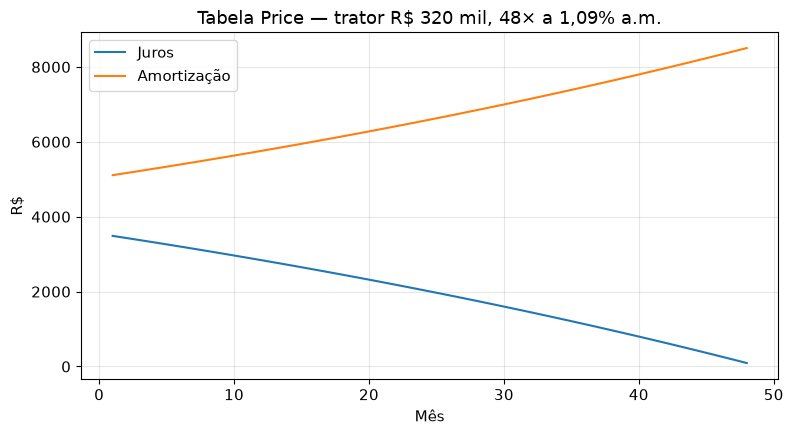

In [7]:
# Observar a estrutura da dívida: juros caem, amortização sobe (parcela fixa)
fig, ax = plt.subplots()
ax.plot(tab["mes"], tab["juros"], label="Juros")
ax.plot(tab["mes"], tab["amortizacao"], label="Amortização")
ax.set_title("Tabela Price — trator R$ 320 mil, 48× a 1,09% a.m.")
ax.set_xlabel("Mês")
ax.set_ylabel("R$")
ax.legend()
plt.show()

In [8]:
# SAC: amortização constante = PV/n; parcela = amortização + juros do mês
def tabela_sac(pv, i, n):
    """Gera DataFrame com a tabela SAC (amortização constante)."""
    amort = pv / n                                   # constante por construção
    linhas = []
    saldo = pv
    for t in range(1, n + 1):
        juros = saldo * i
        linhas.append({"mes": t, "parcela": amort + juros, "juros": juros,
                       "amortizacao": amort, "saldo": saldo - amort})
        saldo -= amort
    return pd.DataFrame(linhas)

sac = tabela_sac(320_000, 0.0109, 48)
print(f"SAC — 1ª parcela: {brl(sac['parcela'].iloc[0])} | 48ª: {brl(sac['parcela'].iloc[-1])}")
print(f"Total pago — SAC: {brl(sac['parcela'].sum())} | Price: {brl(pmt * 48)}")
print(f"Juros totais — SAC: {brl(sac['juros'].sum())} | Price: {brl(pmt * 48 - 320_000)}")

SAC — 1ª parcela: R$ 10.154,67 | 48ª: R$ 6.739,33
Total pago — SAC: R$ 405.456,00 | Price: R$ 412.680,48
Juros totais — SAC: R$ 85.456,00 | Price: R$ 92.680,48


**Comparação executiva:** SAC desembolsa **R$ 405.456,00** no total (R$ 85.456,00 de
juros); Price desembolsa **R$ 412.680,48** (R$ 92.680,48 de juros). A diferença
(~R$ 7.224) é o preço da parcela fixa inicial mais leve. Para o cliente: se o caixa
aguenta a 1ª parcela do SAC (R$ 10.154,67), ele sai mais barato; senão, Price suaviza.

## 5. `try/except`: erros como parte do fluxo

**Intuição.** Planilha de cliente chegou: preços como "R$ 1.234,56", "42,30", células
vazias, "R$ —". Chamar `float()` direto derruba o notebook com `ValueError`. O `try/except`
diz ao Python: *tente isto; se der este erro, faça aquilo em vez de quebrar*.

O livro-base (McKinney, Apêndice A) usa exatamente este exemplo — a função `attempt_float`.

In [9]:
# float() falha com ValueError em texto que não é número;
# attempt_float (McKinney) captura e devolve a entrada intacta
print(float("1.2345"))            # funciona

def attempt_float(x):
    """Versão tolerante de float(): devolve x intacto se não der para converter."""
    try:
        return float(x)
    except (TypeError, ValueError):
        return x

print(attempt_float("1.2345"))    # 1.2345
print(attempt_float("preço?"))    # devolve a própria string, sem quebrar
print(attempt_float(None))        # TypeError também capturado
# NOTA: capture o tipo ESPECÍFICO (nunca 'except:' nuo) — um except sem tipo
# engole bugs de verdade (ZeroDivisionError, typo) e o relatório sai errado.

1.2345
1.2345
preço?
None


**Por que listar os tipos (`TypeError`, `ValueError`)?** `ValueError` é conteúdo ruim
("preço?" como número); `TypeError` é entrada de tipo errado (`None`). Capturar ambos
aqui é deliberado — mas num cálculo, engolir `TypeError` pode esconder um bug nosso.
Regra: no cálculo, capture só o que você sabe tratar; na limpeza de dados, seja mais
tolerante. Veja o caso clássico de divisão:

In [10]:
# ZeroDivisionError: elasticidade com preço igual (ΔP = 0) — e o except certo
def elasticidade_segura(p1, p2, q1, q2):
    """Elasticidade que NÃO quebra quando ΔP = 0 — devolve None com aviso."""
    try:
        return (q2 - q1) / q1 / ((p2 - p1) / p1)
    except ZeroDivisionError:
        print("Aviso: variação de preço nula — elasticidade indefinida.")
        return None

print(elasticidade_segura(38.90, 42.30, 320, 290))   # normal
print(elasticidade_segura(38.90, 38.90, 320, 290))   # ΔP = 0 → None

-1.0726102941176476
Aviso: variação de preço nula — elasticidade indefinida.
None


### `else` e `finally`

- `else`: roda **só quando o `try` deu certo** — separa "o que tenta" de "o que celebra";
- `finally`: roda **sempre**, com ou sem erro — o lugar do registro de auditoria
  ("quantas linhas foram tentadas"). A seção 6 usa os dois de verdade, na limpeza da
  planilha: o `finally` conta toda linha tentada, o caminho feliz guarda o valor.

## 6. Caso real: sanitizando planilha de cliente

**Cenário.** O açougue mandou o controle de vendas em Excel. A coluna de preço vem
no padrão brasileiro: `R$ 1.234,56` (ponto = milhar, vírgula = decimal), com buracos
e sujeira. Antes de qualquer estatística, a coluna precisa virar `float`.

Conversão `"R$ 1.234,56"` → `1234.56`, em 4 passos na ordem certa:
1. `.strip()` — espaços das pontas;
2. tirar o `R$`;
3. `.replace(".", "")` — remover separador de milhar; **depois** `.replace(",", ".")` — vírgula vira ponto decimal;
4. `float()` sob `try/except` — se sobrar lixo, devolve `None` (não quebra o laço).

In [11]:
# A função de limpeza — cada passo com decisão comentada
def limpar_moeda(texto):
    """Converte 'R$ 1.234,56' → 1234.56. Devolve None se não conseguir."""
    if isinstance(texto, (int, float)):        # já é número? nada a fazer
        return float(texto)
    if not isinstance(texto, str):             # None, NaN, datas...
        return None
    limpo = texto.strip()
    limpo = limpo.replace("R$", "").strip()    # remove símbolo da moeda
    limpo = limpo.replace(".", "").replace(",", ".")  # 1.234,56 → 1234,56 → 1234.56
    try:
        return float(limpo)
    except ValueError:
        return None                            # sinaliza 'inválido' sem quebrar

# Teste com a sujeira típica de planilha de cliente
testes = ["R$ 38,90", "  42,30 ", "R$ 1.234,56", "", "R$ —", "R$ 5,40"]
for t in testes:
    print(f"{t!r:16} → {limpar_moeda(t)}")

'R$ 38,90'       → 38.9
'  42,30 '       → 42.3
'R$ 1.234,56'    → 1234.56
''               → None
'R$ —'           → None
'R$ 5,40'        → 5.4


In [12]:
# Planilha (hipotética) de 5.000 linhas do açougue — simulação local, sem rede
precos_sujo = pd.Series(
    ["R$ 38,90", "42,30", "R$ 1.234,56", "", "R$ —", "R$ 5,40", "erro", None] * 625,
    name="preco",
)
print(f"Total de linhas: {len(precos_sujo)}")

# limpeza em lote com try/except embutido + auditoria com finally
def carregar_precos(serie):
    """Converte uma Series de preços sujos em floats + estatística de auditoria."""
    valores, lidas, rejeitadas = [], 0, 0
    for item in serie:
        try:
            valores.append(limpar_moeda(item))
        finally:
            lidas += 1                          # auditoria: SEMPRE conta a linha
        if valores[-1] is None:
            rejeitadas += 1
    ok = sum(v is not None for v in valores)
    return valores, {"lidas": lidas, "validas": ok, "rejeitadas": rejeitadas}

valores, auditoria = carregar_precos(precos_sujo)
print(auditoria)
print(f"Primeiros 8 valores limpos: {valores[:8]}")

Total de linhas: 5000
{'lidas': 5000, 'validas': 3125, 'rejeitadas': 1875}
Primeiros 8 valores limpos: [38.9, 42.3, 1234.56, None, None, 5.4, None, nan]


In [13]:
# Série limpa + estatística descritiva — agora sim, a análise
precos_limpo = pd.Series(valores, name="preco").dropna()
print(precos_limpo.describe().round(2))
print(f"Preço médio: {brl(precos_limpo.mean())}")

count    2500.00
mean      330.29
std       522.38
min         5.40
25%        30.52
50%        40.60
75%       340.36
max      1234.56
Name: preco, dtype: float64
Preço médio: R$ 330,29


**Decisão de design.** `limpar_moeda` devolve `None` em vez de lançar erro. Em código
de análise (vs. software de produção), falhar silenciosamente **com registro** (a
auditoria diz quantas linhas caíram) é melhor do que parar tudo no meio de 5.000 linhas.
Se 40% das linhas caíssem, aí sim paramos e voltamos ao cliente — o número de
rejeitadas é o nosso gatilho.

## 7. Compondo: mini-relatório em uma função

Funções pequenas e testadas se **compõem**: o relatório é só a última função, que
chama as outras.

In [14]:
# Relatório executivo: função que chama funções
def relatorio_acougue(p1, p2, q1, q2):
    """Imprime o diagnóstico de preço de um produto do açougue."""
    eps = elasticidade_arco(p1, p2, q1, q2)
    receita_antes, receita_depois = p1 * q1, p2 * q2
    print(f"Elasticidade (arco): ε = {eps:.2f}")
    print(f"Receita: {brl(receita_antes)} → {brl(receita_depois)} "
          f"({'perdeu' if receita_depois < receita_antes else 'ganhou'})")
    if eps < -1:
        print("Diagnóstico: demanda elástica — aumento de preço reduziu a receita.")
    elif eps > -1:
        print("Diagnóstico: demanda inelástica — preço aguenta novo reajuste.")
    else:
        print("Diagnóstico: elasticidade unitária — receita estável.")

relatorio_acougue(38.90, 42.30, 320, 290)

Elasticidade (arco): ε = -1.17
Receita: R$ 12.448,00 → R$ 12.267,00 (perdeu)
Diagnóstico: demanda elástica — aumento de preço reduziu a receita.


## 📝 Exercícios

### Exercício 1 — Elasticidade do arroz (mercado de Goiânia)

Um mercadinho em Goiânia subiu o pacote de 5 kg de arroz de R$ 5,40 para R$ 5,89 e a
venda mensal caiu de 1.200 para 1.080 pacotes. Calcule ε com a função da aula
(`elasticidade_preco`), diga se a demanda é elástica ou inelástica e o que acontece com
a receita (calcule P·Q antes e depois).

In [15]:
# EXERCÍCIO 1 — seu código aqui


In [16]:
# SOLUÇÃO 1 — elasticidade e receita do arroz
eps_arroz = elasticidade_preco(5.40, 5.89, 1200, 1080)
print(f"ε = {eps_arroz:.3f}")
receita_antes, receita_depois = 5.40 * 1200, 5.89 * 1080
print(f"Receita antes: {brl(receita_antes)} | depois: {brl(receita_depois)}")
if abs(eps_arroz) > 1:
    print("Demanda elástica (|ε| > 1): reajuste derrubou a receita.")
else:
    print("Demanda inelástica (|ε| ≤ 1): reajuste aumentou a receita.")

ε = -1.102
Receita antes: R$ 6.480,00 | depois: R$ 6.361,20
Demanda elástica (|ε| > 1): reajuste derrubou a receita.


### Exercício 2 — Financiamento com entrada

O trator de R$ 320.000 teve **entrada de R$ 32.000** e o resto será financiado em
**36 meses** a 1,09% a.m. Use `pmt_price` para achar a parcela. Atenção: a parcela é
calculada sobre o valor **financiado** (R$ 288.000), não sobre o valor do bem.

In [17]:
# EXERCÍCIO 2 — seu código aqui


In [18]:
# SOLUÇÃO 2 — parcela sobre o valor financiado
pv_financiado = 320_000 - 32_000                 # R$ 288.000
parcela_36 = pmt_price(pv_financiado, 0.0109, 36)
print(f"Parcela: {brl(parcela_36)}")
print(f"Total pago: {brl(parcela_36 * 36)} | juros: {brl(parcela_36 * 36 - pv_financiado)}")

Parcela: R$ 9.714,96
Total pago: R$ 349.738,54 | juros: R$ 61.738,54


### Exercício 3 — SAC vs Price

Com os mesmos argumentos da aula (PV = R$ 320.000, i = 1,09% a.m., n = 48), gere as
duas tabelas e responda: (a) qual a primeira e a última parcela do SAC? (b) qual
sistema tem menor total de juros? (c) se o cliente só consegue pagar R$ 9.000/mês,
qual sistema é viável?

In [19]:
# EXERCÍCIO 3 — seu código aqui


In [20]:
# SOLUÇÃO 3 — comparação SAC × Price
sac_ex = tabela_sac(320_000, 0.0109, 48)
price_ex = tabela_price(320_000, 0.0109, 48)
print(f"(a) SAC: 1ª parcela {brl(sac_ex['parcela'].iloc[0])} "
      f"→ última {brl(sac_ex['parcela'].iloc[-1])}")
print(f"(b) Juros totais — SAC: {brl(sac_ex['juros'].sum())} "
      f"| Price: {brl(price_ex['juros'].sum())}")
print(f"(c) Parcela inicial do SAC vs teto de R$ 9.000: "
      f"{sac_ex['parcela'].iloc[0] > 9_000}")
print("    → SAC passa do teto; Price (R$ 8.597,51) é o único viável.")

(a) SAC: 1ª parcela R$ 10.154,67 → última R$ 6.739,33
(b) Juros totais — SAC: R$ 85.456,00 | Price: R$ 92.680,48
(c) Parcela inicial do SAC vs teto de R$ 9.000: True
    → SAC passa do teto; Price (R$ 8.597,51) é o único viável.


### Exercício 4 — Sanitizar uma lista suja

Converta a lista abaixo em números, contando válidos e rejeitados:
`["R$ 38,90", "42,30", "R$ 1.234,56", "", "R$ —", "  5,40 "]`. Use `limpar_moeda`.

In [21]:
# EXERCÍCIO 4 — seu código aqui


In [22]:
# SOLUÇÃO 4 — reutilizar a função da seção 6
lista_suja = ["R$ 38,90", "42,30", "R$ 1.234,56", "", "R$ —", "  5,40 "]
lista_limpa = [limpar_moeda(x) for x in lista_suja]
print(f"Valores: {lista_limpa}")
n_validos = sum(v is not None for v in lista_limpa)
print(f"Válidos: {n_validos} | Rejeitados: {len(lista_limpa) - n_validos}")

Valores: [38.9, 42.3, 1234.56, None, None, 5.4]
Válidos: 4 | Rejeitados: 2


### Exercício 5 — `vpl` blindada

Modifique o `vpl` da seção 3 para **lançar** `ValueError` quando (a) `taxa <= 0` ou
(b) `fluxos[0] >= 0` (investimento deve ser negativo). Assinatura: `def vpl(taxa, fluxos):`.
Teste com o silo e depois com uma taxa inválida, capturando o erro.

In [23]:
# EXERCÍCIO 5 — seu código aqui


In [24]:
# SOLUÇÃO 5 — vpl com validação + teste do erro
def vpl(taxa, fluxos):
    """VPL com validação de entrada (lança ValueError em entradas sem sentido)."""
    if taxa <= 0:
        raise ValueError("Taxa de desconto deve ser positiva (ex.: 0.139 = 13,9% a.a.).")
    if fluxos[0] >= 0:
        raise ValueError("fluxos[0] deve ser o investimento, negativo (ex.: -850_000).")
    return sum(fc / (1 + taxa) ** t for t, fc in enumerate(fluxos))

fluxos_silo_ex = [-850_000, 280_000, 310_000, 290_000, 300_000, 260_000]
print(f"VPL silo: {brl(vpl(0.139, fluxos_silo_ex))}")

try:
    vpl(0, fluxos_silo_ex)         # taxa inválida
except ValueError as erro:
    print(f"ValueError capturado: {erro}")

VPL silo: R$ 144.919,77
ValueError capturado: Taxa de desconto deve ser positiva (ex.: 0.139 = 13,9% a.a.).


## 📌 Resumo & para casa

- **Função pura** = fórmula testável: entra dado, sai resultado, sem efeitos colaterais — `elasticidade_preco`, `elasticidade_arco`, `pmt_price`, `tabela_price`, `tabela_sac`, `vpl`.
- **Argumentos**: posicionais (essenciais, ordem fixa), nomeados (auto-explicativos), valores padrão (convenções do escritório).
- **`try/except`** protege a análise de dados sujos; capturar o tipo específico (`ValueError`, `ZeroDivisionError`); `finally` para auditoria.
- **Sanitização em 4 passos**: strip → tirar R$ → remover ponto de milhar → vírgula por ponto → `float` sob proteção.
- Composição: relatórios são funções que chamam funções — construa o vocabulário uma vez, use em todo projeto.

**Para casa:** refaça `limpar_moeda` aceitando também `"1.234,56 neg"` (devolva `None`) e
adicione à tabela Price uma coluna `juros_acumulados` (soma corrente dos juros).
Leia: `kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md`
(seções *Functions* e *Exception handling*) e
`kb/02_vanderplas_python_data_science_handbook/04_chapter-1.md`.

**Próxima aula:** Aula 06 — essas mesmas fórmulas viram **classes** (`ProjetoInvestimento`
com `.calcular_vpl()` e `.payback()`): dados e cálculo passam a viajar juntos.